In [1]:
#load the best models from the checkpoints folder

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical 
from tensorflow.keras.models import load_model, Model
import json
import helper
import plotly.express as px

MODEL_ID = 143#35
AVERAGED = 5

2024-01-18 16:43:12.284913: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
params = []
#load the json from params.json
with open('params.json') as json_file:
    params = json.load(json_file)
params = params[MODEL_ID]
print(params)
model = load_model('checkpoints/best_model_{}.h5'.format(MODEL_ID), compile=False)

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


2024-01-18 16:43:14.284918: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-18 16:43:14.284970: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
#load the data
group_size = params['group_size'] if AVERAGED == None else AVERAGED
def avg(group, group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res
data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
#print all the columns
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                    (data.index.get_level_values('Peptide').isin(ANTIGENS))
                ]
data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
antigen = list(data.index.get_level_values('Peptide'))
times = list(data.index.get_level_values('Time'))
concentration = list(data.index.get_level_values('Concentration'))
scaling_factor = 1024/(params['output_range'][1]-params['output_range'][0])
X = np.array(data.values)/scaling_factor + params['output_range'][0]
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
y = to_categorical(y)


extractor = Model(inputs=model.inputs,
                    outputs=model.get_layer("Bottleneck").output)
embedding = np.array(extractor(X))
output = np.argmax(y,axis=1)
ANTIGENS = ["null", "E1", "G4", "V4", "T4", "Q4", "A2", "N4"]
output = np.array(ANTIGENS)[output]
num_embedding_dimensions = embedding.shape[1]
df = pd.DataFrame(embedding, columns=['Dimension '+str(i+1) for i in range(num_embedding_dimensions)])
df["Antigen"] = output
df["Time"] = times
df["Concentration"] = concentration

In [4]:
for i in range(len(data.columns)):
    df[data.columns[i]] = X[:,i]

In [5]:
def get_2d_plot(df,title,color):
    #get the min and max of the two dimensions
    x_range= [min(df['Dimension 1']),max(df['Dimension 1'])]
    y_range= [min(df['Dimension 2']),max(df['Dimension 2'])]
    fig = px.scatter(
        df,
        x='Dimension 1',
        y='Dimension 2',
        color=color,
        title=title,
        range_x=x_range,
        range_y=y_range,
        opacity=0.1
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(legend_title="Antigen")
    fig.show()

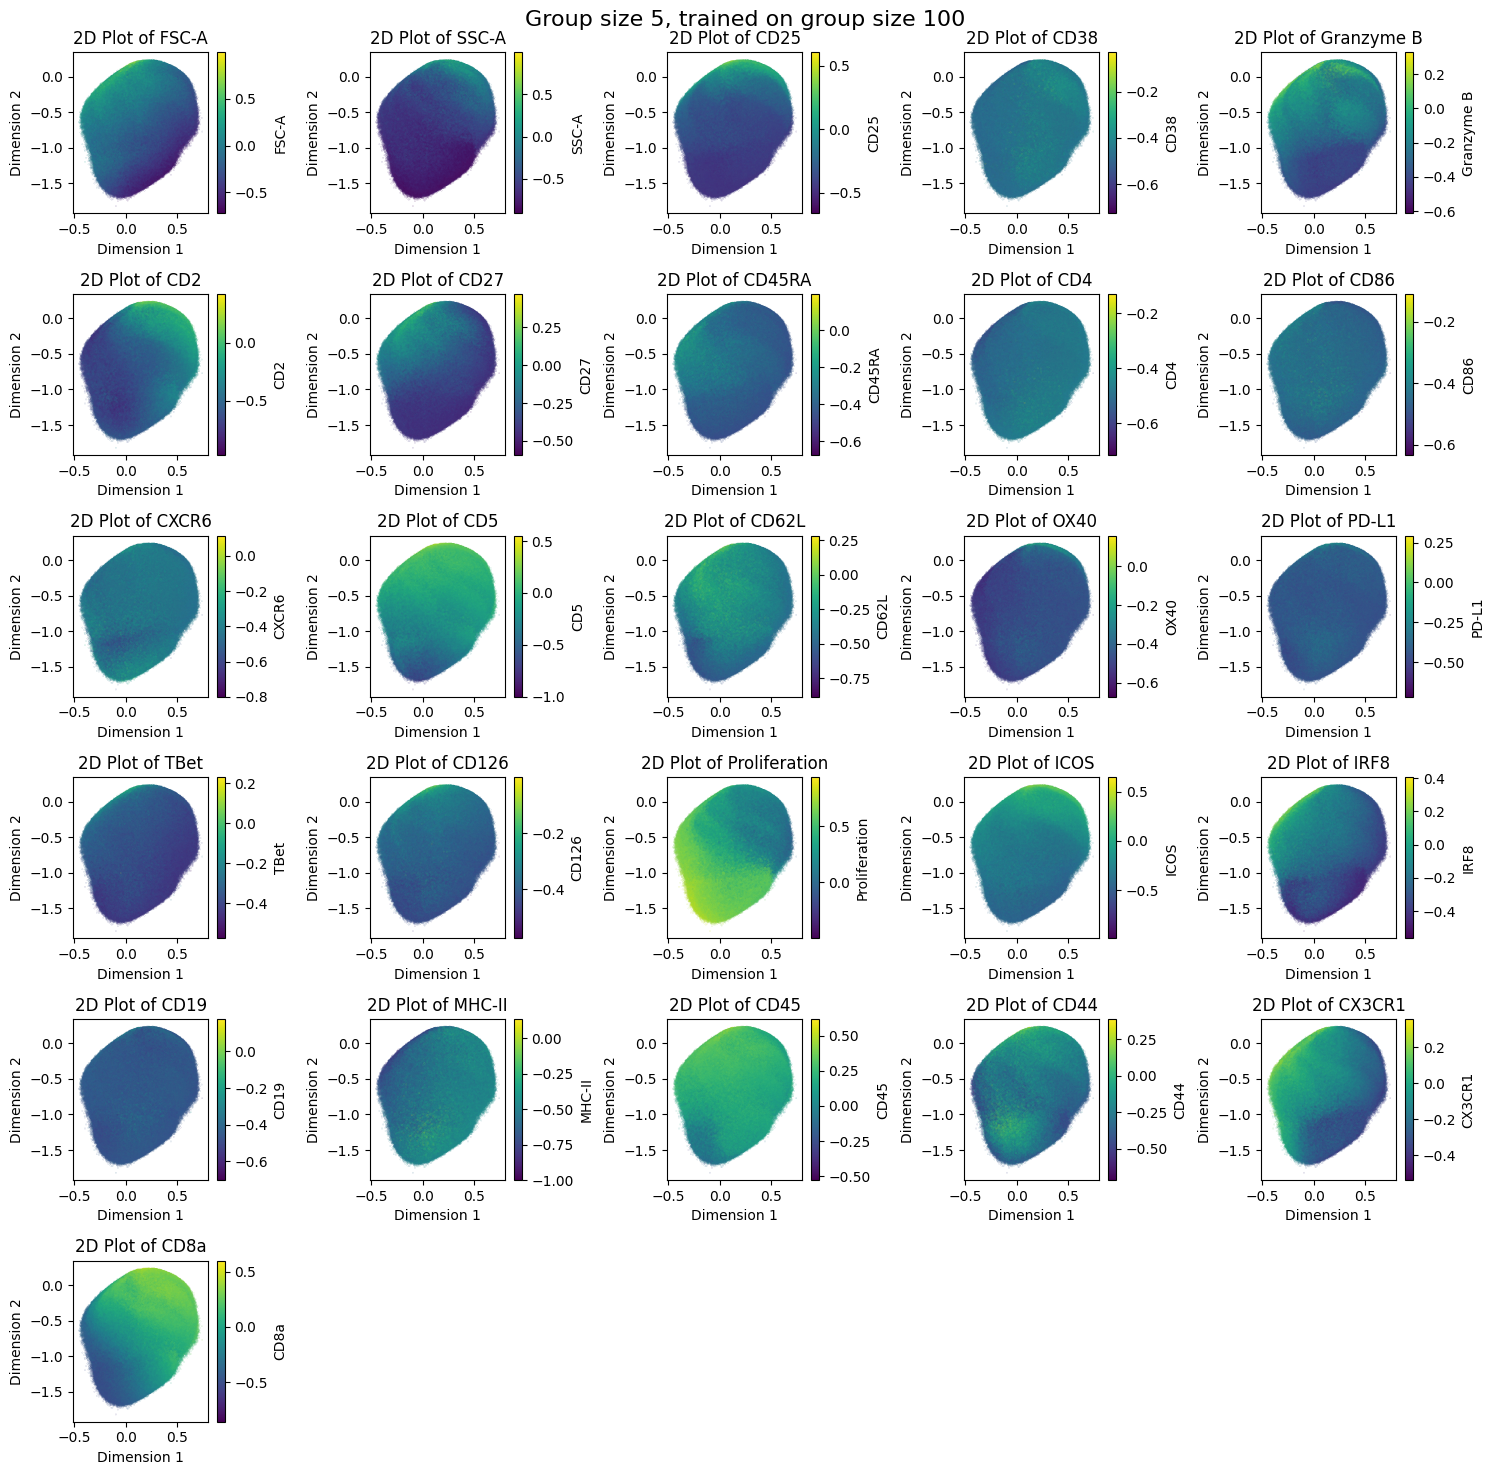

In [6]:
markers = data.columns
plt.figure(figsize=(15, 15))
plt.suptitle("Group size {}, trained on group size {}".format(group_size,params['group_size']), fontsize=16)
for i in range(len(markers)):
    plt.subplot(6, 5, i + 1)
    plt.scatter(df['Dimension 1'], df['Dimension 2'], c=df[markers[i]], s=0.005)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title('2D Plot of ' + markers[i])
    plt.colorbar(label=markers[i])
plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()